In [1]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('titanic')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/titanic


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

print('all success')

all success


In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
#Person's status helps us to determine whether they survived or not
train['Title'] = train['Name'].str.split(', ').str[1].str.split('.').str[0]
test['Title'] = test['Name'].str.split(', ').str[1].str.split('.').str[0]

#with the help X_train['Title'].value_counts()
popular_titles = ['Mr','Miss','Mrs','Master']

train['Title'] = train['Title'].apply(lambda x: x if x in popular_titles else 'Rare')
test['Title'] = test['Title'].apply(lambda x: x if x in popular_titles else 'Rare')
train['Title'].value_counts()

Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

In [5]:
#delete useless columns 
drop_columns = ['PassengerId','Name','Ticket','Cabin']

y = train['Survived']
X = train.drop(drop_columns + ['Survived'], axis=1)

G = test['PassengerId']
X_test = test.drop(drop_columns, axis=1)

print("Данные подготовлены!")
print(f"Train shape: {X.shape}")
print(f"Test shape: {X_test.shape}")

Данные подготовлены!
Train shape: (891, 8)
Test shape: (418, 8)


In [6]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       714 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  889 non-null    object 
 7   Title     891 non-null    object 
dtypes: float64(2), int64(3), object(3)
memory usage: 55.8+ KB


In [7]:
#split of data
X_train, X_valid, y_train, y_valid = train_test_split(X,y,test_size=0.2, random_state = 42,stratify=y)
print(f"Размер X_train: {X_train.shape}, X_valid: {X_valid.shape}")
print(f'Train distribution: {y_train.value_counts(normalize=True)}')
print(f'Val distribution: {y_valid.value_counts(normalize=True)}')

Размер X_train: (712, 8), X_valid: (179, 8)
Train distribution: Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64
Val distribution: Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


In [8]:
#split datatypes
numeric_columns = ['Age','SibSp','Parch','Fare']
categorial_columns = ['Sex','Embarked','Title']
ordinal_columns = list(set(list(X.columns)) - set(numeric_columns) - set(categorial_columns))

#for numeric
numeric_transformer = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

#for categories
categorial_transformer = Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('scaler',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

#cat + num + ord
preprocessor = ColumnTransformer([
    ('num',numeric_transformer,numeric_columns),
    ('cat',categorial_transformer,categorial_columns),
    ('ord','passthrough',ordinal_columns)
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'SibSp', 'Parch', 'Fare']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('scaler',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Sex', 'Embarked', 'Title']),
                                ('ord', 'passthrough', ['Pclass'])])

In [9]:
# build the pipeline and fit the model.
pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('classifier',RandomForestClassifier(random_state=42))
])

pipeline.fit(X_train,y_train)
y_pred = pipeline.predict(X_valid)

print('Model has been fitted')

Model has been fitted


In [10]:
from sklearn.model_selection import GridSearchCV

# 1. Сетка параметров для поиска
param_grid = {
    'classifier__n_estimators': [50, 100, 200],       # Количество деревьев в лесу
    'classifier__max_depth': [3, 5, 10, None],        # Максимальная глубина каждого дерева
    'classifier__min_samples_split': [2, 5, 10]       # Минимум объектов для разбиения
}

# 2. Настройка поиска
grid_search = GridSearchCV(
    pipeline,              # Наш пайплайн (preprocessor + RandomForest)
    param_grid,            # Сетка для перебора
    cv=5,                  # 5-кратная кросс-валидация
    scoring='accuracy',    # Метрика для сравнения моделей
    n_jobs=-1,             # Используем все ядра процессора (ускоряет)
    verbose=1              # Показываем прогресс
)

# 3. Запускаем поиск
print("⏳ Идет поиск лучших параметров... (это займёт 1-2 минуты)")
grid_search.fit(X_train, y_train)

# 4. Результаты
print("\n✅ Лучшие параметры:", grid_search.best_params_)
print("✅ Лучшее качество на кросс-валидации:", round(grid_search.best_score_, 4))
best_pipeline = grid_search.best_estimator_


⏳ Идет поиск лучших параметров... (это займёт 1-2 минуты)
Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Лучшие параметры: {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
✅ Лучшее качество на кросс-валидации: 0.8217


In [11]:
y_pred_best = best_pipeline.predict(X_valid)

Качество модели на валидации:
Accuracy:  0.8212
Precision: 0.8246
Recall:    0.6812
F1-score:  0.7460


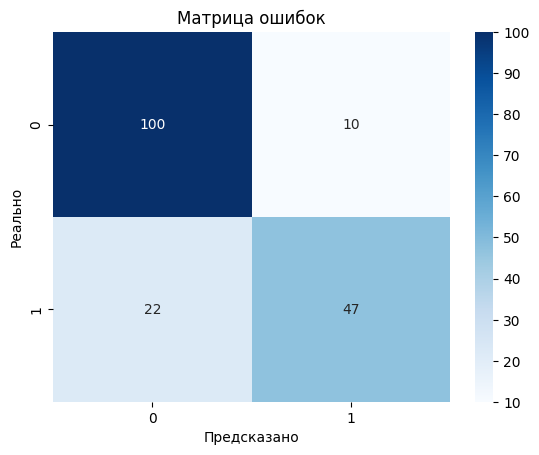

In [12]:
acc = accuracy_score(y_valid, y_pred_best)
prec = precision_score(y_valid, y_pred_best)
rec = recall_score(y_valid, y_pred_best)
f1 = f1_score(y_valid, y_pred_best)


print("Качество модели на валидации:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

# Матрица ошибок
cm = confusion_matrix(y_valid, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок')
plt.xlabel('Предсказано')
plt.ylabel('Реально')
plt.show()

In [13]:
test = best_pipeline.predict(X_test)
submission = pd.DataFrame({'PassengerId': G, 'Survived': test})

submission.to_csv('submission.csv', index=False)
print("Файл submission.csv готов к загрузке!")

Файл submission.csv готов к загрузке!
